In [1]:
!pip install yfinance pandas numpy matplotlib scipy

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [4]:
tickers = {
    "BTC": "BTC-USD",
    "ETH": "ETH-USD",
    "SOL": "SOL-USD",
    "XRP": "XRP-USD",
    "ADA": "ADA-USD"
}

start_date = "2023-01-01"

prices = yf.download(
    list(tickers.values()),
    start=start_date,
    auto_adjust=True,
    progress=False
)["Close"]

prices.columns = list(tickers.keys())
prices = prices.dropna()

print("Data starts from:", prices.index.min())
print("Data ends at:", prices.index.max())

prices.tail()

Data starts from: 2023-01-01 00:00:00
Data ends at: 2026-05-16 00:00:00


,BTC,ETH,SOL,XRP,ADA
Date,,,,,
2026-05-12,0.270914,80477.492188,2274.643555,94.284294,1.436101
2026-05-13,0.264659,79277.117188,2257.576416,91.085472,1.426346
2026-05-14,0.270159,81051.250000,2280.934814,92.148727,1.484111
2026-05-15,0.261488,79065.679688,2223.328857,89.200356,1.433731
2026-05-16,0.255400,78273.359375,2181.709961,86.830002,1.417100


In [5]:
returns = np.log(prices / prices.shift(1)).dropna()

returns.tail()

,BTC,ETH,SOL,XRP,ADA
Date,,,,,
2026-05-12,-0.034894,-0.015423,-0.028054,-0.032000,-0.027957
2026-05-13,-0.023359,-0.015028,-0.007532,-0.034516,-0.006816
2026-05-14,0.020569,0.022132,0.010294,0.011606,0.039700
2026-05-15,-0.032622,-0.024803,-0.025580,-0.032519,-0.034536
2026-05-16,-0.023557,-0.010072,-0.018897,-0.026933,-0.011668


In [6]:
weights = pd.Series({
    "BTC": 0.45,
    "ETH": 0.30,
    "SOL": 0.10,
    "XRP": 0.10,
    "ADA": 0.05
})

basket_return = returns.mul(weights, axis=1).sum(axis=1)

basket_return.tail()

Date
2026-05-12   -0.027732
2026-05-13   -0.019566
2026-05-14    0.020070
2026-05-15   -0.029658
2026-05-16   -0.018789
dtype: float64

In [7]:
basket_index = 100 * np.exp(basket_return.cumsum())

basket_index.tail()

Date
2026-05-12    238.768828
2026-05-13    234.142570
2026-05-14    238.889379
2026-05-15    231.908537
2026-05-16    227.591971
dtype: float64

In [8]:
rolling_window = 30

basket_vol_30d = basket_return.rolling(rolling_window).std() * np.sqrt(365)

latest_sigma = basket_vol_30d.dropna().iloc[-1]

print("Latest annualized basket volatility:", round(latest_sigma, 4))
print("Latest annualized basket volatility (%):", round(latest_sigma * 100, 2), "%")

Latest annualized basket volatility: 0.3402
Latest annualized basket volatility (%): 34.02 %


In [11]:
def black_scholes_call(S0, K, r, T, sigma):
    """
    Black-Scholes price for a European call option.

    Parameters:
    S0    : current index level
    K     : strike price
    r     : annual risk-free rate
    T     : time to maturity in years
    sigma : annualized volatility

    Returns:
    call option price
    """
    if sigma <= 0 or T <= 0:
        return max(S0 - K * np.exp(-r * T), 0)

    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

    return call_price

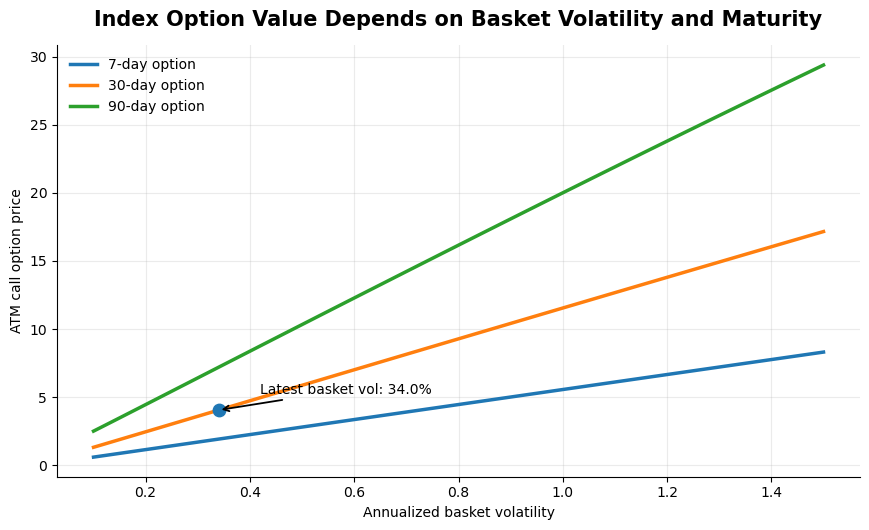

In [16]:
sigma_grid = np.linspace(0.10, 1.50, 120)

S0 = 100
K = 100
r = 0.04

maturities = {
    "7-day option": 7 / 365,
    "30-day option": 30 / 365,
    "90-day option": 90 / 365
}

fig, ax = plt.subplots(figsize=(8.8, 5.4))

for label, T_i in maturities.items():
    prices_i = [
        black_scholes_call(S0, K, r, T_i, sigma)
        for sigma in sigma_grid
    ]
    ax.plot(
        sigma_grid,
        prices_i,
        linewidth=2.5,
        label=label
    )

ax.scatter(
    latest_sigma,
    black_scholes_call(S0, K, r, 30 / 365, latest_sigma),
    s=80,
    zorder=3
)

ax.annotate(
    f"Latest basket vol: {latest_sigma:.1%}",
    xy=(latest_sigma, black_scholes_call(S0, K, r, 30 / 365, latest_sigma)),
    xytext=(latest_sigma + 0.08, black_scholes_call(S0, K, r, 30 / 365, latest_sigma) + 1.2),
    arrowprops=dict(arrowstyle="->", lw=1.3),
    fontsize=10
)

ax.set_title(
    "Index Option Value Depends on Basket Volatility and Maturity",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Annualized basket volatility")
ax.set_ylabel("ATM call option price")

ax.legend(frameon=False)
ax.grid(True, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "index_option_price_volatility_maturity_sensitivity.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()